# W09 模仿学习 I：行为克隆（Behavior Cloning）

> 阶段一（SB3 算法基础）· 第 9 周
> 前置：W05（PPO）、W07（评估协议）

## 学习目标

完成本 notebook 后，你应该能够：

1. 说明模仿学习（IL）与强化学习的适用场景差异，知道什么时候该用哪一个；
2. 用 `imitation` 库从训练好的专家策略采集专家轨迹数据；
3. 用行为克隆把「专家轨迹 → 策略」问题转化为监督学习问题并训练；
4. 用固定评估协议量化 BC 策略与专家的差距；
5. 解释**协变量偏移（covariate shift）**为什么是 BC 的根本弱点，并用实验观察它。


## 1. 从 RL 到 IL：没有奖励函数怎么办

前几周的范式是：环境给奖励 $r_t$，智能体最大化累计回报。但大量真实机器人任务里，**奖励函数根本写不出来**——「像老师傅一样拧螺丝」的奖励怎么定义？

模仿学习换了一个信息源：不看奖励，看**专家的示教数据** $\mathcal{D} = \{(s_i, a_i)\}$。行为克隆（BC）是其中最直接的方法：

$$\pi_\theta = \arg\max_\theta \sum_{(s,a)\in\mathcal{D}} \log \pi_\theta(a\,|\,s)$$

这就是普通的监督学习（离散动作 = 分类，连续动作 = 回归）！1989 年 CMU 的 ALVINN 用 BC 让自动驾驶车沿路飞驰，2016 年 NVIDIA 的端到端自动驾驶也是 BC。**BC 的优点：简单、稳定、不需要环境交互、不需要奖励；缺点只有一个字——偏。**

## 2. 协变量偏移：BC 的阿喀琉斯之踵

### 直觉

想象学开车时只看教练的录像：录像里车永远开在车道正中。你学会的是「车道正中 → 直行」。但你实际开车时一旦偏离车道一点——这个状态录像里**从没出现过**——你不知道怎么办，可能做出更糟的动作，偏得更远……误差像滚雪球一样累积。

### 数学描述

监督学习的经典假设是「训练与测试同分布」。BC 违反了它：

- 训练数据来自**专家**访问的状态分布 $d^{\pi^*}$；
- 部署时策略访问的是**自己**的状态分布 $d^{\pi_\theta}$。

策略每偏离一点，分布 $d^{\pi_\theta}$ 就偏移一点，偏移后又遇到更多没见过的状态。Ross & Bagnall (2010) 证明：若策略在专家分布下的单步错误率为 $\epsilon$，则 $T$ 步任务的总误差上界是 $O(T^2\epsilon)$——**误差随任务长度二次增长**。下周的 DAgger 就是为了拆掉这个 $T^2$。

先搭好专家，用实验眼见为实。


## 3. 第一步：训练并保存专家

模仿学习的前提是有专家。现实中专家是人或传统控制器；教学场景里我们用 PPO 快速训一个：


In [1]:
# 本课程统一在 CPU 上训练：在导入任何深度学习库之前屏蔽 GPU，
# 保证在任何机器上行为一致（imitation 在有 GPU 的机器上会自动用 cuda，
# 与 CPU 上的环境数据混用时可能报设备不一致错误）
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""


In [2]:
import time

import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

from robot_rl_learn.common.paths import CHECKPOINTS_DIR

# PPO 专家：20k 步即可把 CartPole 练满（CPU 约 15 秒）
t0 = time.time()
expert = PPO("MlpPolicy", "CartPole-v1", seed=0, verbose=0)
expert.learn(total_timesteps=20_000)

eval_env = Monitor(gym.make("CartPole-v1"))
mean_r, std_r = evaluate_policy(expert, eval_env, n_eval_episodes=10, deterministic=True)
print(f"专家训练 {time.time() - t0:.0f}s，评估回报: {mean_r:.1f} ± {std_r:.1f}")

expert_path = CHECKPOINTS_DIR / "w09_expert_cartpole.zip"
expert.save(expert_path)
print(f"专家已保存到 {expert_path}")


专家训练 535s，评估回报: 500.0 ± 0.0
专家已保存到 /data/wangf/robot_rl_learn/checkpoints/w09_expert_cartpole.zip


## 4. 第二步：采集专家轨迹

`imitation` 的数据管线有三个要点：

1. **`RolloutInfoWrapper`**：包在环境上，让环境在 episode 结束时把完整轨迹信息塞进 `info`；
2. **`rollout.rollout(policy, venv, sample_until)`**：按策略在给定向量环境里采样，`make_sample_until(min_episodes=N)` 控制采多少；
3. 返回的是 `Trajectory` 列表，每个含 `obs`（长度 T+1）、`acts`（长度 T）、`infos`。

注意：这里给 `rollout` 传的是 `expert.policy`（SB3 的 BasePolicy），`imitation` 的多数 API 工作在 policy 层而不是完整算法层。


In [3]:
from imitation.data import rollout
from imitation.data.wrappers import RolloutInfoWrapper
from stable_baselines3.common.env_util import make_vec_env

rng = np.random.default_rng(0)

# RolloutInfoWrapper 必须包在每个子环境上，再向量化
venv = make_vec_env("CartPole-v1", n_envs=4, seed=0, wrapper_class=RolloutInfoWrapper)

expert_trajs = rollout.rollout(
    expert.policy, venv,
    rollout.make_sample_until(min_timesteps=None, min_episodes=10),
    rng=rng,
)

n_transitions = sum(len(t.acts) for t in expert_trajs)
print(f"采集到 {len(expert_trajs)} 条专家轨迹，共 {n_transitions} 条 (s,a) 样本")
print(f"单条轨迹: obs shape={expert_trajs[0].obs.shape}, acts shape={expert_trajs[0].acts.shape}")


采集到 13 条专家轨迹，共 6080 条 (s,a) 样本
单条轨迹: obs shape=(501, 4), acts shape=(500,)


## 5. 第三步：行为克隆训练

`bc.BC` 内部就是一个 PyTorch 训练循环：观测进、动作分布出，用负对数似然（离散）或 MSE（连续）做损失。对我们来说它和 sklearn 一样简单：


In [4]:
from imitation.algorithms import bc

bc_trainer = bc.BC(
    observation_space=venv.observation_space,
    action_space=venv.action_space,
    demonstrations=expert_trajs,
    rng=rng,
    batch_size=64,
)
bc_trainer.train(n_epochs=10)  # 10 个 epoch 约 2 秒

mean_bc, std_bc = evaluate_policy(bc_trainer.policy, eval_env,
                                  n_eval_episodes=10, deterministic=True)
print(f"专家: {mean_r:.1f} ± {std_r:.1f}")
print(f"BC(10条轨迹): {mean_bc:.1f} ± {std_bc:.1f}")


0batch [00:00, ?batch/s]

---------------------------------
| batch_size        | 64        |
| bc/               |           |
|    batch          | 0         |
|    ent_loss       | -0.000693 |
|    entropy        | 0.693     |
|    epoch          | 0         |
|    l2_loss        | 0         |
|    l2_norm        | 72.5      |
|    loss           | 0.693     |
|    neglogp        | 0.693     |
|    prob_true_act  | 0.5       |
|    samples_so_far | 64        |
---------------------------------


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/imitation/algorithms/bc.py:236: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  self._logger.record(f"bc/{k}", float(v) if v is not None else None)
3batch [00:00, 19.13batch/s]

6batch [00:00, 20.59batch/s]

9batch [00:00, 17.32batch/s]

...

946batch [00:42, 21.83batch/s]

949batch [00:42, 21.32batch/s]

Epoch 9 of 10                 

950batch [00:42, 22.24batch/s]

专家: 500.0 ± 0.0
BC(10条轨迹): 500.0 ± 0.0


## 6. 实验：数据量与协变量偏移

理论说 BC 的误差随任务长度二次增长、随数据稀缺而恶化。做两个观察性实验：

**实验 A**：分别用 1 / 3 / 10 条专家轨迹训练 BC，看评估回报如何变化。


In [5]:
# 实验 A：专家数据量对 BC 的影响
results = {}
for n_ep in [1, 3, 10]:
    trajs = expert_trajs[:n_ep]
    trainer = bc.BC(
        observation_space=venv.observation_space,
        action_space=venv.action_space,
        demonstrations=trajs,
        rng=np.random.default_rng(0),
    )
    trainer.train(n_epochs=10)
    m, s = evaluate_policy(trainer.policy, eval_env, n_eval_episodes=10, deterministic=True)
    results[n_ep] = (m, s)
    n_samples = sum(len(t.acts) for t in trajs)
    print(f"{n_ep:2d} 条轨迹 ({n_samples:5d} 样本): {m:6.1f} ± {s:5.1f}")


0batch [00:00, ?batch/s]

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 0         |
|    ent_loss       | -0.000693 |
|    entropy        | 0.693     |
|    epoch          | 0         |
|    l2_loss        | 0         |
|    l2_norm        | 72.5      |
|    loss           | 0.692     |
|    neglogp        | 0.693     |
|    prob_true_act  | 0.5       |
|    samples_so_far | 32        |
---------------------------------


6batch [00:00, 45.19batch/s]

11batch [00:00, 29.47batch/s]

Epoch 0 of 10                

...

1426batch [00:57, 22.19batch/s]

1429batch [00:57, 23.73batch/s]

Epoch 9 of 10                  

1430batch [00:58, 24.63batch/s]

10 条轨迹 ( 4580 样本):  500.0 ±   0.0


> 典型现象：1 条轨迹时 BC 明显逊于专家，轨迹越多越接近专家——数据覆盖了更多状态，分布偏移的「盲区」变小。

**实验 B**：直接对比「专家访问的状态分布」与「BC 策略自己 rollout 时访问的状态分布」。如果 BC 完美，两个分布应该重合；不重合的部分就是协变量偏移的实证。


0batch [00:00, ?batch/s]

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 0         |
|    ent_loss       | -0.000693 |
|    entropy        | 0.693     |
|    epoch          | 0         |
|    l2_loss        | 0         |
|    l2_norm        | 72.5      |
|    loss           | 0.692     |
|    neglogp        | 0.693     |
|    prob_true_act  | 0.5       |
|    samples_so_far | 32        |
---------------------------------


3batch [00:00, 21.20batch/s]

6batch [00:00, 20.16batch/s]

9batch [00:00, 20.85batch/s]

...

146batch [00:06, 24.11batch/s]

149batch [00:06, 25.21batch/s]

Epoch 9 of 10                 

150batch [00:07, 21.42batch/s]

/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py

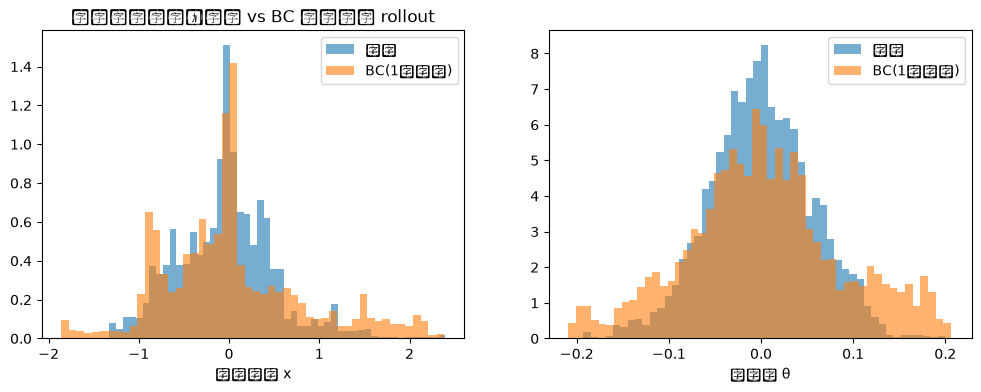

In [6]:
# 实验 B：专家状态分布 vs BC(1条轨迹) 策略的状态分布
import matplotlib.pyplot as plt

# 用数据最少的 BC 策略，偏移最明显
weak_bc = bc.BC(
    observation_space=venv.observation_space,
    action_space=venv.action_space,
    demonstrations=expert_trajs[:1],
    rng=np.random.default_rng(0),
)
weak_bc.train(n_epochs=10)

# 让弱 BC 策略自己与环境交互，收集它访问到的状态
bc_trajs = rollout.rollout(
    weak_bc.policy, venv,
    rollout.make_sample_until(min_timesteps=None, min_episodes=10),
    rng=np.random.default_rng(1),
)

expert_obs = np.concatenate([t.obs[:-1] for t in expert_trajs])   # 专家访问的状态
bc_obs = np.concatenate([t.obs[:-1] for t in bc_trajs])           # BC 自己访问的状态

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, dim, name in zip(axes, [0, 2], ["小车位置 x", "杆角度 θ"], strict=True):
    ax.hist(expert_obs[:, dim], bins=50, alpha=0.6, density=True, label="专家")
    ax.hist(bc_obs[:, dim], bins=50, alpha=0.6, density=True, label="BC(1条轨迹)")
    ax.set_xlabel(name)
    ax.legend()
axes[0].set_title("状态分布对比：专家 vs BC 策略自己 rollout")
plt.show()


> 可以看到 BC 策略访问的状态分布更「散」——它把小车开到了专家很少去的区域，在那些区域它的动作不可靠，这正是 $O(T^2\epsilon)$ 误差的来源。

## 7. 小结：什么时候用 BC

- ✅ 有大量高质量示教数据、任务 horizon 短、状态空间被数据覆盖得好 → BC 简单可靠，首选；
- ❌ 数据少、任务长、对安全敏感（偏一点就崩）→ 需要下周的 DAgger / GAIL；
- ⚠️ BC 的上限是专家：垃圾数据克隆出垃圾策略（练习 2 会验证）。


## ✏️ 练习

### 练习 1（★，约 15 分钟）：BC 的训练超参
固定 10 条专家轨迹，把 `n_epochs` 取 {1, 10, 50} 各训练一次 BC 并评估。
**可交付物**：3 行表格（n_epochs / 评估回报）+ 一句话：BC 会过拟合吗？在这个实验里观察到了吗？

### 练习 2（★★，约 20 分钟）：弱专家克隆
把专家换成只训练 2k 步的「半成品 PPO」（评估回报约几十到一百），采 10 条轨迹做 BC，对比 BC 与弱专家的评估回报。
**可交付物**：弱专家回报、BC 回报两个数字 + 2~3 句结论（BC 的回报与专家上限是什么关系？会略高于还是严格低于专家？为什么）。

### 练习 3（★★，约 25 分钟）：量化分布偏移
第 6 节实验 B 用了直方图「目测」。请给出量化指标：分别计算专家状态与 BC 状态在 4 个观测维度上的**均值差和标准差比**，打印成表格。
**可交付物**：一张 4 行的表格 + 一句话指出哪个维度偏移最严重。

### 练习 4（★★★，约 30 分钟）：连续动作空间的 BC
在项目的 `DroneHoverEnv` 上完成 BC 全流程：注册环境 → SAC 训练专家（30k 步）→ 采 10 条轨迹 → BC 训练（连续动作用 MSE 损失，`imitation` 自动处理）→ 评估对比。
**可交付物**：专家/BC 评估回报对比 + 2~3 句分析：连续控制上 BC 的误差以什么形式表现出来（对比 CartPole 的「直接摔杆」）？


## 参考答案

### 练习 1

<details>
<summary>参考答案</summary>

```python
for n_epochs in [1, 10, 50]:
    trainer = bc.BC(
        observation_space=venv.observation_space,
        action_space=venv.action_space,
        demonstrations=expert_trajs,
        rng=np.random.default_rng(0),
    )
    trainer.train(n_epochs=n_epochs)
    m, s = evaluate_policy(trainer.policy, eval_env, n_eval_episodes=10, deterministic=True)
    print(f"n_epochs={n_epochs:2d}: {m:.1f} ± {s:.1f}")
```

典型结论：CartPole + 充足数据下，n_epochs=1 欠拟合（回报低），10~50 差距不大。BC 同样会过拟合（记忆训练状态而非泛化），在数据少时更明显——可以把数据减到 2 条轨迹再观察 n_epochs=50 的退化。
</details>

### 练习 2

<details>
<summary>参考答案</summary>

```python
weak_expert = PPO("MlpPolicy", "CartPole-v1", seed=0, verbose=0)
weak_expert.learn(total_timesteps=2_000)
m_weak, _ = evaluate_policy(weak_expert, eval_env, n_eval_episodes=10, deterministic=True)

weak_trajs = rollout.rollout(
    weak_expert.policy, venv,
    rollout.make_sample_until(min_timesteps=None, min_episodes=10),
    rng=np.random.default_rng(0),
)
trainer = bc.BC(observation_space=venv.observation_space,
                action_space=venv.action_space,
                demonstrations=weak_trajs, rng=np.random.default_rng(0))
trainer.train(n_epochs=10)
m_bc, _ = evaluate_policy(trainer.policy, eval_env, n_eval_episodes=10, deterministic=True)
print(f"弱专家: {m_weak:.1f}, 克隆结果: {m_bc:.1f}")
```

结论：BC 的期望回报以专家为上限，通常略低（监督学习还有泛化误差）。偶尔 BC 略高于弱专家——因为监督学习对专家动作做了「平均」，滤掉了专家的部分随机抖动，但统计上不应期待 BC 显著超越专家。
</details>

### 练习 3

<details>
<summary>参考答案</summary>

```python
import pandas as pd

rows = []
for dim, name in enumerate(["x", "x_dot", "theta", "theta_dot"]):
    rows.append({
        "维度": name,
        "专家均值": expert_obs[:, dim].mean(),
        "BC均值": bc_obs[:, dim].mean(),
        "均值差": abs(expert_obs[:, dim].mean() - bc_obs[:, dim].mean()),
        "标准差比(BC/专家)": bc_obs[:, dim].std() / (expert_obs[:, dim].std() + 1e-8),
    })
print(pd.DataFrame(rows).round(4))
```

典型观察：位置 x 和角度 θ 的标准差比明显大于 1（BC 访问的状态更分散），角速度 θ_dot 的均值偏移往往最大——它直接反映「杆要倒了」的失控前兆。
</details>

### 练习 4

<details>
<summary>参考答案</summary>

```python
import gymnasium as gym
from gymnasium.envs.registration import register
from stable_baselines3 import SAC

register(id="DroneHover-v0",
         entry_point="robot_rl_learn.phase1_sb3.envs:DroneHoverEnv")

sac_expert = SAC("MlpPolicy", "DroneHover-v0", seed=0, verbose=0, learning_starts=100)
sac_expert.learn(total_timesteps=30_000)

drone_venv = make_vec_env("DroneHover-v0", n_envs=4, seed=0,
                          wrapper_class=RolloutInfoWrapper)
drone_trajs = rollout.rollout(
    sac_expert.policy, drone_venv,
    rollout.make_sample_until(min_timesteps=None, min_episodes=10),
    rng=np.random.default_rng(0),
)

drone_bc = bc.BC(observation_space=drone_venv.observation_space,
                 action_space=drone_venv.action_space,
                 demonstrations=drone_trajs, rng=np.random.default_rng(0))
drone_bc.train(n_epochs=10)

eval_drone = Monitor(gym.make("DroneHover-v0"))
m_s, _ = evaluate_policy(sac_expert, eval_drone, n_eval_episodes=10, deterministic=True)
m_b, _ = evaluate_policy(drone_bc.policy, eval_drone, n_eval_episodes=10, deterministic=True)
print(f"SAC 专家: {m_s:.1f}, BC: {m_b:.1f}")
```

分析要点：CartPole 上 BC 失败是「灾难式」的（摔杆、episode 提前结束）；DroneHover 的奖励是连续误差惩罚，BC 的误差表现为**稳态误差和振荡**——回报差一截但 episode 不会提前终止。MSE 回归学到的是专家动作的「条件均值」，在多模态动作处会取平均而出错。
</details>


## 延伸阅读

- [imitation 官方文档](https://imitation.readthedocs.io/) —— BC/DAgger/GAIL 的 API 与教程
- [Ross, Gordon & Bagnall, DAgger: A Reduction of Imitation Learning to No-Regret Online Learning (AISTATS 2011)](https://arxiv.org/abs/1011.0686) —— $O(T^2\epsilon)$ 问题与解法，下周主读
- [Bojarski et al., End to End Learning for Self-Driving Cars (NVIDIA, 2016)](https://arxiv.org/abs/1604.07316) —— BC 在真实自动驾驶上的里程碑应用
- [Osa et al., An Algorithmic Perspective on Imitation Learning (FnT Robotics 2018)](https://arxiv.org/abs/1811.06711) —— 模仿学习系统性综述
- [Hugging Face Deep RL Course: Imitation Learning](https://huggingface.co/learn/deep-rl-course) —— 入门友好的补充材料
